In [1]:
import os
import json
import random
import pickle
import datetime

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import kagglehub


2026-05-12 04:08:44.518938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778558924.711237      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778558924.767573      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778558925.206778      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778558925.206817      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778558925.206819      23 computation_placer.cc:177] computation placer alr

In [2]:
SEEDS = [42, 123, 2024, 3407, 777]

BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 5
IMAGE_SIZE = (224, 224)
LEARNING_RATE = 1e-5
FINE_TUNE_LAYERS = 20
AUTOTUNE = tf.data.AUTOTUNE

EXPERIMENT_NAME = "MobileNetV2_PlantVillage"
EXPECTED_NUM_CLASSES = 3


In [3]:
dataset_path = kagglehub.dataset_download("faysalmiah1721758/potato-dataset")
DATASET_DIR = dataset_path

print("Dataset directory:", DATASET_DIR)


Dataset directory: /kaggle/input/datasets/faysalmiah1721758/potato-dataset


In [4]:
class_names = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

NUM_CLASSES = len(class_names)

print("Detected classes:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("Number of classes:", NUM_CLASSES)

assert NUM_CLASSES == EXPECTED_NUM_CLASSES, f"Expected {EXPECTED_NUM_CLASSES}, found {NUM_CLASSES}"


Detected classes:
0: Potato___Early_blight
1: Potato___Late_blight
2: Potato___healthy
Number of classes: 3


In [5]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

file_paths = []
labels = []

for label_index, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)

    for fname in os.listdir(class_dir):
        if fname.lower().endswith(valid_extensions):
            file_paths.append(os.path.join(class_dir, fname))
            labels.append(label_index)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total images:", len(labels))

unique, counts = np.unique(labels, return_counts=True)
print("\nClass distribution:")
for idx, count in zip(unique, counts):
    print(f"{class_names[idx]}: {count}")


Total images: 2152

Class distribution:
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152


In [6]:
def load_dataset_mobilenet(file_paths, labels, augment=False, shuffle=True, seed=None):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def process(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])

        image = tf.image.resize(image, IMAGE_SIZE)
        image = tf.cast(image, tf.float32)

        if augment:
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, max_delta=25.5)
            image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
            image = tf.clip_by_value(image, 0.0, 255.0)

        image = preprocess_input(image)
        label = tf.one_hot(label, depth=NUM_CLASSES)

        return image, label

    ds = ds.map(process, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(file_paths),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds


In [7]:
def build_mobilenet_v2(num_classes, input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    backbone = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    backbone.trainable = True

    for layer in backbone.layers[:-FINE_TUNE_LAYERS]:
        layer.trainable = False

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="MobileNetV2_3class_finetuned"
    )

    return model


In [8]:
def count_model_parameters(model):
    total_params = model.count_params()

    trainable_params = np.sum([
        np.prod(v.shape) for v in model.trainable_weights
    ])

    non_trainable_params = np.sum([
        np.prod(v.shape) for v in model.non_trainable_weights
    ])

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Non-trainable parameters: {non_trainable_params:,}")

    return total_params, trainable_params, non_trainable_params


In [9]:
def run_single_seed(seed):
    print("\n" + "=" * 70)
    print(f"Running seed: {seed}")
    print("=" * 70)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    X_train, X_temp, y_train, y_temp = train_test_split(
        file_paths,
        labels,
        test_size=0.20,
        stratify=labels,
        random_state=seed
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=seed
    )

    print(f"Train: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    class_weight_vals = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=y_train
    )
    class_weight = dict(enumerate(class_weight_vals))

    print("Class weights:", class_weight)

    train_ds = load_dataset_mobilenet(X_train, y_train, augment=True, shuffle=True, seed=seed)
    val_ds = load_dataset_mobilenet(X_val, y_val, augment=False, shuffle=False, seed=seed)
    test_ds = load_dataset_mobilenet(X_test, y_test, augment=False, shuffle=False, seed=seed)

    model = build_mobilenet_v2(num_classes=NUM_CLASSES)

    total_params, trainable_params, non_trainable_params = count_model_parameters(model)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    os.makedirs("models", exist_ok=True)
    os.makedirs("history", exist_ok=True)
    os.makedirs("reports", exist_ok=True)

    run_name = f"{EXPERIMENT_NAME}_{NUM_CLASSES}class_seed_{seed}"

    model_path = f"models/{run_name}.keras"
    history_path = f"history/{run_name}_history.pkl"
    plot_path = f"history/{run_name}_accuracy_loss.png"
    cm_path = f"history/{run_name}_confusion_matrix.png"
    report_path = f"reports/{run_name}_classification_report.json"

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop, checkpoint],
        class_weight=class_weight
    )

    stopped_epoch = len(history.history["loss"])
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    with open(history_path, "wb") as f:
        pickle.dump(history.history, f)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    y_true = []
    y_pred = []

    for images, batch_labels in test_ds:
        probs = model.predict(images, verbose=0)
        y_true.extend(np.argmax(batch_labels.numpy(), axis=1))
        y_pred.extend(np.argmax(probs, axis=1))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    with open(report_path, "w") as f:
        json.dump(report_dict, f, indent=4)

    print(f"\nSeed {seed} Test Accuracy: {test_acc:.4f}")
    print(f"Seed {seed} Test Loss: {test_loss:.4f}")
    print(f"Seed {seed} Stopped Epoch: {stopped_epoch}")
    print(f"Seed {seed} Best Epoch: {best_epoch}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        xticks_rotation=45
    )
    plt.title(f"Confusion Matrix - Seed {seed}")
    plt.tight_layout()
    plt.savefig(cm_path, dpi=300)
    plt.show()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.show()

    return {
        "seed": seed,
        "num_classes": NUM_CLASSES,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "stopped_epoch": stopped_epoch,
        "best_epoch": best_epoch,
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_precision": report_dict["weighted avg"]["precision"],
        "weighted_recall": report_dict["weighted avg"]["recall"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"],
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "model_path": model_path,
        "history_path": history_path,
        "plot_path": plot_path,
        "confusion_matrix_path": cm_path,
        "classification_report_path": report_path
    }



Running seed: 42
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}


I0000 00:00:1778558950.953805      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/tmp/ipykernel_23/3140933403.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total parameters: 2,261,827
Trainable parameters: 1,209,923
Non-trainable parameters: 1,051,904
Epoch 1/50


I0000 00:00:1778558967.705369      66 service.cc:152] XLA service 0x7d3ec82137f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778558967.705429      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778558969.058721      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-12 04:09:33.921065: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 04:09:34.117854: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778558977.954692      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proc

53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4080 - loss: 1.0860

2026-05-12 04:09:44.872023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 04:09:45.070710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 411ms/step - accuracy: 0.4115 - loss: 1.0799 - val_accuracy: 0.4140 - val_loss: 1.1072
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7664 - loss: 0.5052 - val_accuracy: 0.5767 - val_loss: 0.8870
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8838 - loss: 0.3324 - val_accuracy: 0.6791 - val_loss: 0.6947
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9286 - loss: 0.2242 - val_accuracy: 0.7581 - val_loss: 0.5843
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9374 - loss: 0.2046 - val_accuracy: 0.8093 - val_loss: 0.4713
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9419 - loss: 0.1745 - val_accuracy: 0.8651 - val_loss: 0.3626
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9671 - loss: 0.1279 - val_accuracy: 0.9070 - val_loss: 0.3085
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9776 - loss: 0.0993 - val_accuracy: 0.9209 - val_loss: 

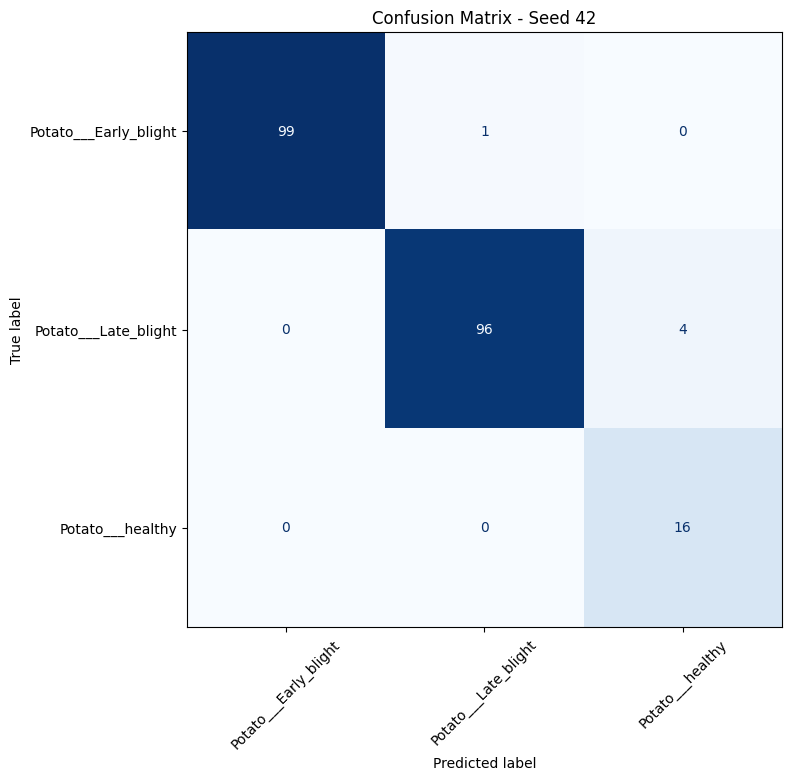

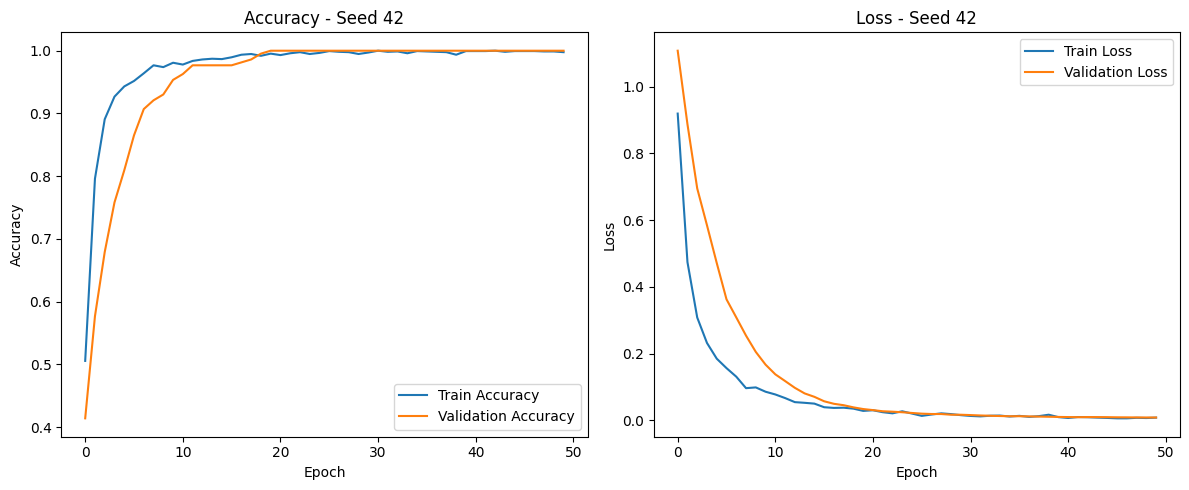


Running seed: 123
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}


/tmp/ipykernel_23/3140933403.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Total parameters: 2,261,827
Trainable parameters: 1,209,923
Non-trainable parameters: 1,051,904
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 303ms/step - accuracy: 0.3286 - loss: 1.0642 - val_accuracy: 0.1674 - val_loss: 1.6319
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7487 - loss: 0.5200 - val_accuracy: 0.2558 - val_loss: 1.2817
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8656 - loss: 0.3378 - val_accuracy: 0.3814 - val_loss: 1.0609
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9377 - loss: 0.2284 - val_accuracy: 0.5163 - val_loss: 0.8740
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9448 - loss: 0.1752 - val_accuracy: 0.6140 - val_loss: 0.7405
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9620 - loss: 0.1341 - val_accuracy: 0.6977 - val_loss: 0.6300
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9592 - loss: 0.1311 - val_accuracy: 0.7721 - val_loss: 0.5115
Epoch 8/50
54

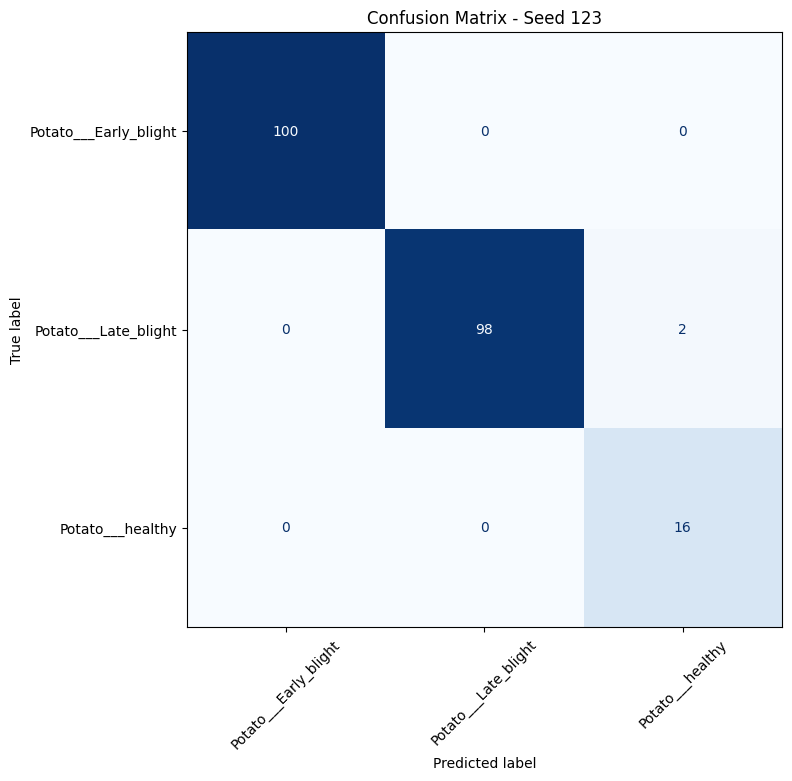

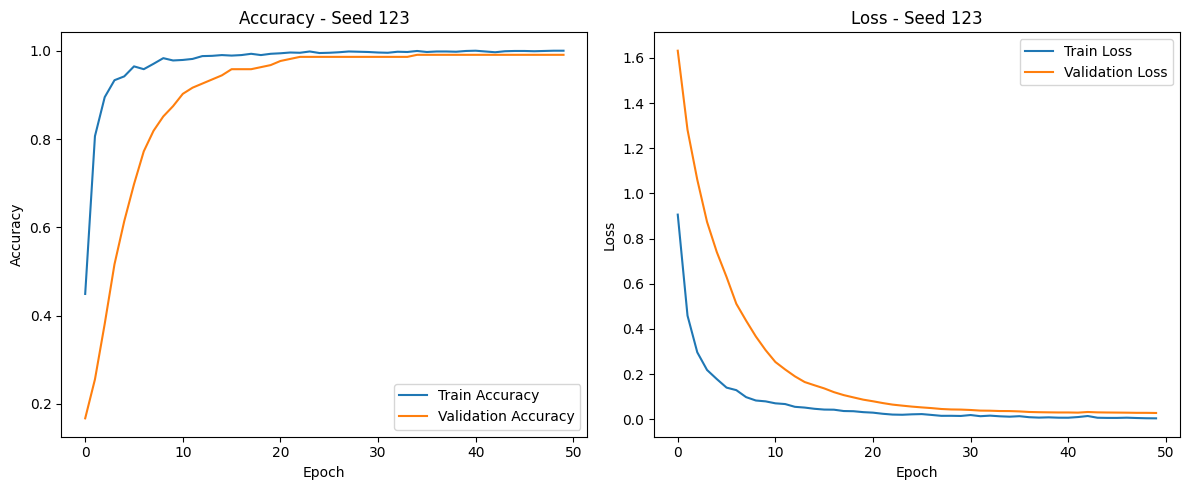


Running seed: 2024
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}


/tmp/ipykernel_23/3140933403.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Total parameters: 2,261,827
Trainable parameters: 1,209,923
Non-trainable parameters: 1,051,904
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 308ms/step - accuracy: 0.1892 - loss: 1.4396 - val_accuracy: 0.3860 - val_loss: 1.3788
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5895 - loss: 0.6585 - val_accuracy: 0.3953 - val_loss: 1.5077
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8804 - loss: 0.3602 - val_accuracy: 0.4419 - val_loss: 1.5028
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9315 - loss: 0.2407 - val_accuracy: 0.4605 - val_loss: 1.4314
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9496 - loss: 0.1705 - val_accuracy: 0.5116 - val_loss: 1.2864
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9577 - loss: 0.1438 - val_accuracy: 0.5721 - val_loss: 1.1124
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9670 - loss: 0.1189 - val_accuracy: 0.6233 - val_loss: 0.9694
Epoch 8/50
54

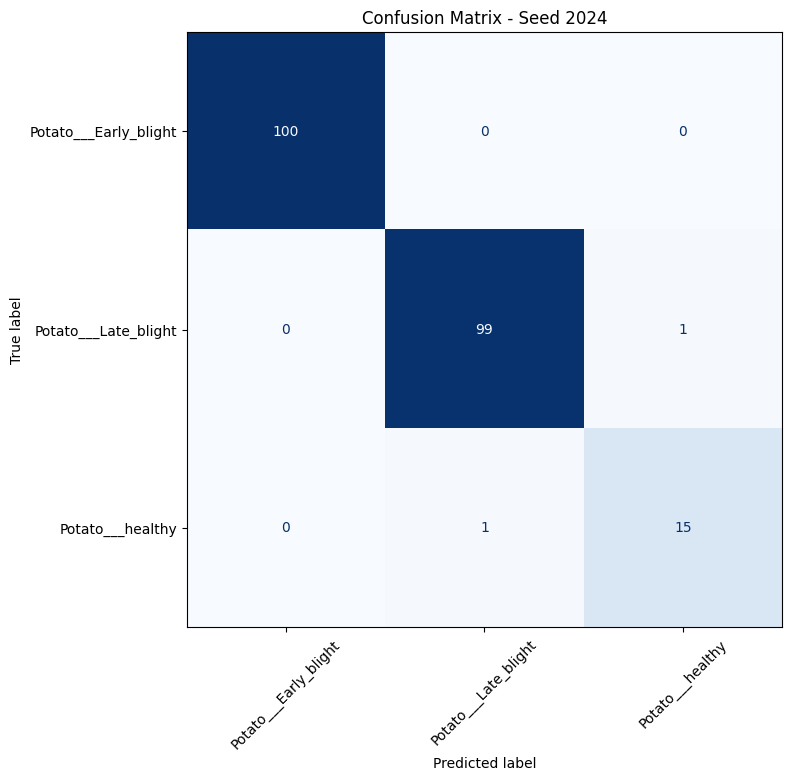

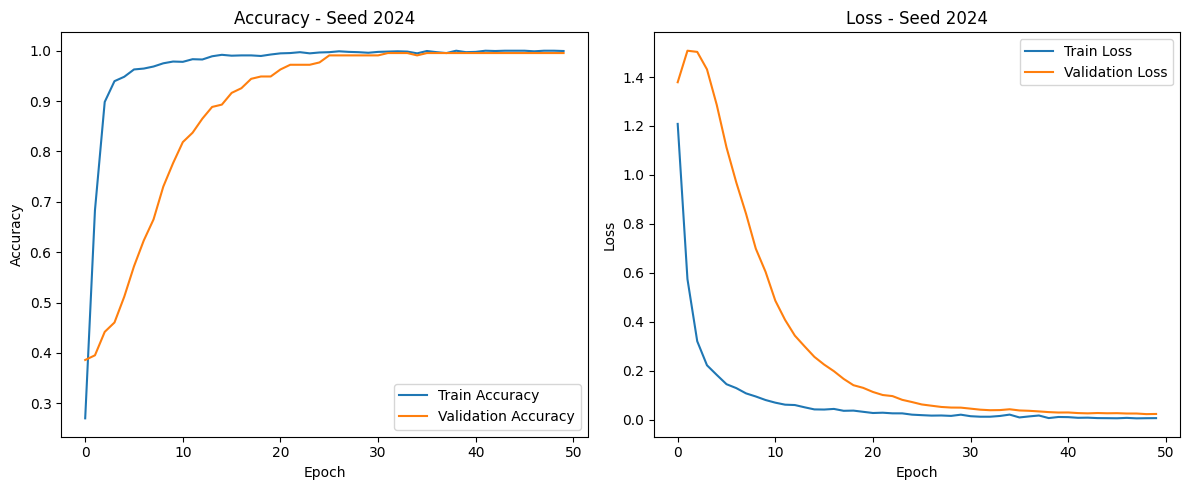


Running seed: 3407
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}


/tmp/ipykernel_23/3140933403.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Total parameters: 2,261,827
Trainable parameters: 1,209,923
Non-trainable parameters: 1,051,904
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 305ms/step - accuracy: 0.3646 - loss: 1.0922 - val_accuracy: 0.4930 - val_loss: 1.1087
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.7182 - loss: 0.5320 - val_accuracy: 0.5814 - val_loss: 0.9183
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8948 - loss: 0.3093 - val_accuracy: 0.6465 - val_loss: 0.7965
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9342 - loss: 0.2255 - val_accuracy: 0.6744 - val_loss: 0.7008
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9478 - loss: 0.1692 - val_accuracy: 0.7163 - val_loss: 0.6263
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9634 - loss: 0.1342 - val_accuracy: 0.7349 - val_loss: 0.5224
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9656 - loss: 0.1302 - val_accuracy: 0.7628 - val_loss: 0.4622
Epoch 8/50
54

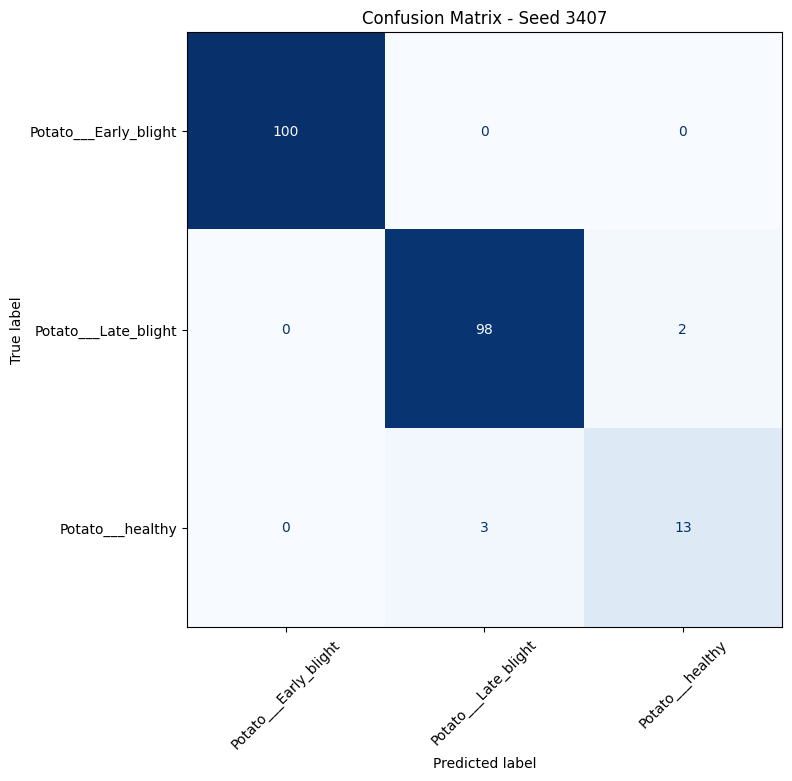

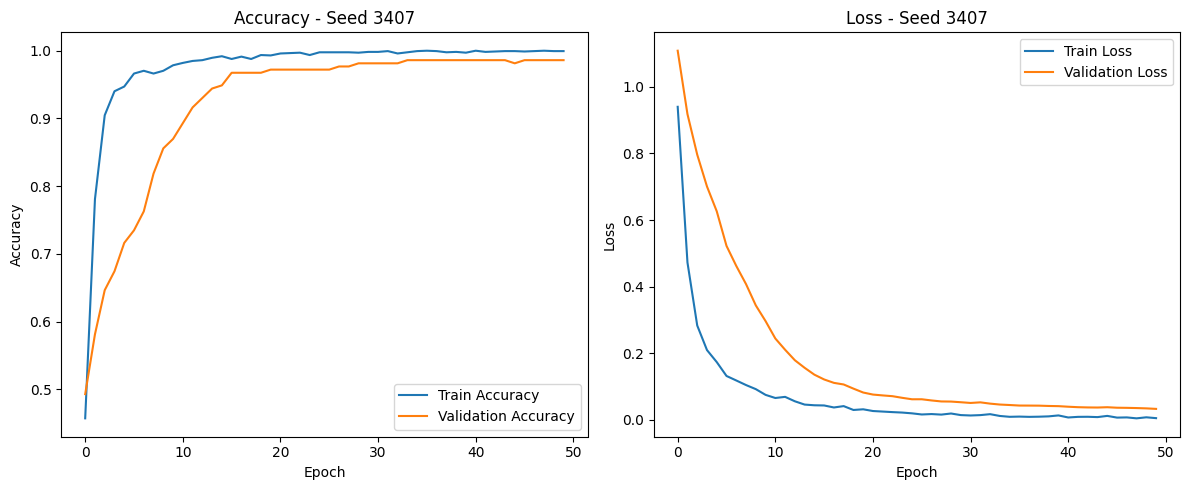


Running seed: 777
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}


/tmp/ipykernel_23/3140933403.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Total parameters: 2,261,827
Trainable parameters: 1,209,923
Non-trainable parameters: 1,051,904
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 300ms/step - accuracy: 0.3627 - loss: 1.0436 - val_accuracy: 0.4186 - val_loss: 1.0649
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.7784 - loss: 0.4896 - val_accuracy: 0.5023 - val_loss: 0.9270
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8984 - loss: 0.2857 - val_accuracy: 0.6186 - val_loss: 0.7753
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9347 - loss: 0.2271 - val_accuracy: 0.6884 - val_loss: 0.6706
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9497 - loss: 0.1967 - val_accuracy: 0.7581 - val_loss: 0.5634
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9653 - loss: 0.1351 - val_accuracy: 0.8047 - val_loss: 0.4761
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9770 - loss: 0.1044 - val_accuracy: 0.8372 - val_loss: 0.4117
Epoch 8/50
54

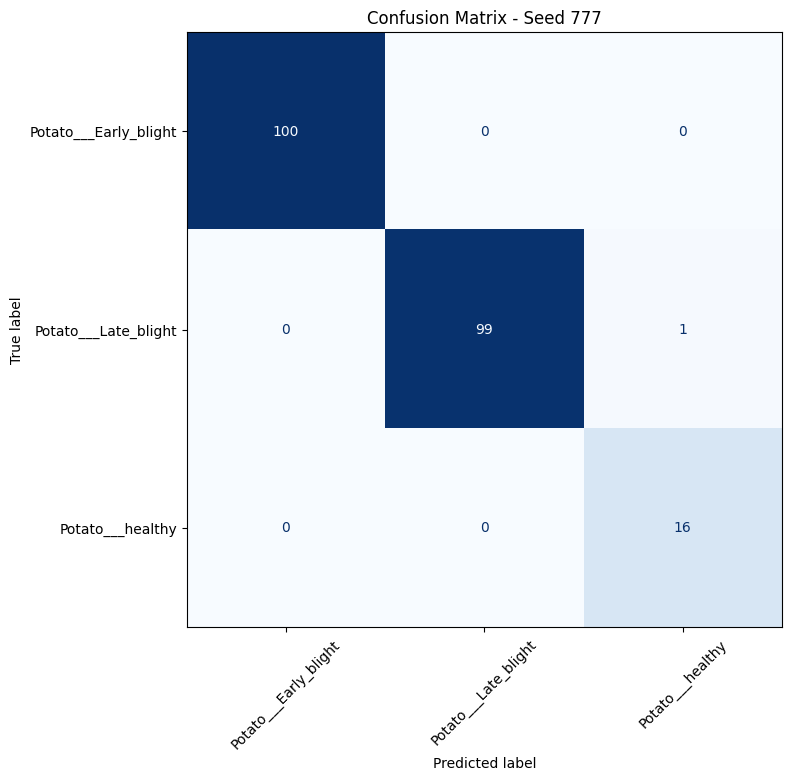

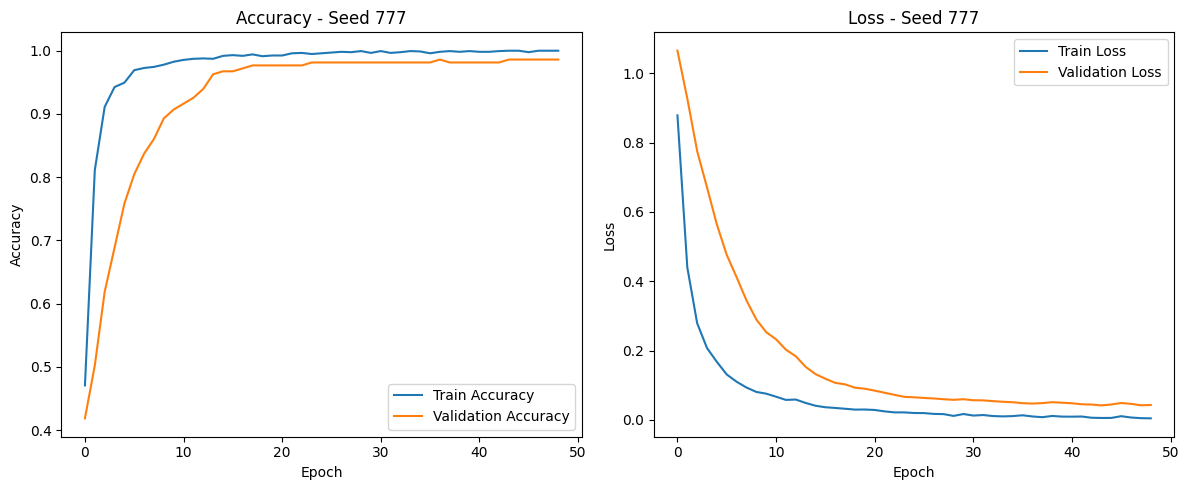


All seed results:
{'seed': 42, 'num_classes': 3, 'test_accuracy': 0.9768518805503845, 'test_loss': 0.04891932010650635, 'stopped_epoch': 50, 'best_epoch': 50, 'macro_precision': 0.9298969072164948, 'macro_recall': 0.9833333333333334, 'macro_f1': 0.9528276842002832, 'weighted_precision': 0.9804123711340206, 'weighted_recall': 0.9768518518518519, 'weighted_f1': 0.9776927712658255, 'total_params': 2261827, 'trainable_params': np.int64(1209923), 'non_trainable_params': np.int64(1051904), 'model_path': 'models/MobileNetV2_PlantVillage_3class_seed_42.keras', 'history_path': 'history/MobileNetV2_PlantVillage_3class_seed_42_history.pkl', 'plot_path': 'history/MobileNetV2_PlantVillage_3class_seed_42_accuracy_loss.png', 'confusion_matrix_path': 'history/MobileNetV2_PlantVillage_3class_seed_42_confusion_matrix.png', 'classification_report_path': 'reports/MobileNetV2_PlantVillage_3class_seed_42_classification_report.json'}
{'seed': 123, 'num_classes': 3, 'test_accuracy': 0.9907407164573669, 'test

In [10]:
all_results = []

for seed in SEEDS:
    result = run_single_seed(seed)
    all_results.append(result)

print("\nAll seed results:")
for result in all_results:
    print(result)


In [11]:
results_df = pd.DataFrame(all_results)

csv_path = f"{EXPERIMENT_NAME}_{NUM_CLASSES}class_multiseed_results.csv"
results_df.to_csv(csv_path, index=False)

print("Saved results to:", csv_path)
results_df


Saved results to: MobileNetV2_PlantVillage_3class_multiseed_results.csv


,seed,num_classes,test_accuracy,test_loss,stopped_epoch,best_epoch,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,total_params,trainable_params,non_trainable_params,model_path,history_path,plot_path,confusion_matrix_path,classification_report_path
0,42,3,0.976852,0.048919,50,50,0.929897,0.983333,0.952828,0.980412,0.976852,0.977693,2261827,1209923,1051904,models/MobileNetV2_PlantVillage_3class_seed_42...,history/MobileNetV2_PlantVillage_3class_seed_4...,history/MobileNetV2_PlantVillage_3class_seed_4...,history/MobileNetV2_PlantVillage_3class_seed_4...,reports/MobileNetV2_PlantVillage_3class_seed_4...
1,123,3,0.990741,0.037562,50,50,0.962963,0.993333,0.977025,0.991770,0.990741,0.990966,2261827,1209923,1051904,models/MobileNetV2_PlantVillage_3class_seed_12...,history/MobileNetV2_PlantVillage_3class_seed_1...,history/MobileNetV2_PlantVillage_3class_seed_1...,history/MobileNetV2_PlantVillage_3class_seed_1...,reports/MobileNetV2_PlantVillage_3class_seed_1...
2,2024,3,0.990741,0.018446,50,49,0.975833,0.975833,0.975833,0.990741,0.990741,0.990741,2261827,1209923,1051904,models/MobileNetV2_PlantVillage_3class_seed_20...,history/MobileNetV2_PlantVillage_3class_seed_2...,history/MobileNetV2_PlantVillage_3class_seed_2...,history/MobileNetV2_PlantVillage_3class_seed_2...,reports/MobileNetV2_PlantVillage_3class_seed_2...
3,3407,3,0.976852,0.061594,50,50,0.945655,0.930833,0.937945,0.976372,0.976852,0.976536,2261827,1209923,1051904,models/MobileNetV2_PlantVillage_3class_seed_34...,history/MobileNetV2_PlantVillage_3class_seed_3...,history/MobileNetV2_PlantVillage_3class_seed_3...,history/MobileNetV2_PlantVillage_3class_seed_3...,reports/MobileNetV2_PlantVillage_3class_seed_3...
4,777,3,0.995370,0.025113,49,44,0.980392,0.996667,0.988224,0.995643,0.995370,0.995429,2261827,1209923,1051904,models/MobileNetV2_PlantVillage_3class_seed_77...,history/MobileNetV2_PlantVillage_3class_seed_7...,history/MobileNetV2_PlantVillage_3class_seed_7...,history/MobileNetV2_PlantVillage_3class_seed_7...,reports/MobileNetV2_PlantVillage_3class_seed_7...


In [12]:
metrics = [
    "test_accuracy",
    "test_loss",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "stopped_epoch",
    "best_epoch"
]

summary_rows = []

for metric in metrics:
    values = results_df[metric].astype(float).values

    summary_rows.append({
        "metric": metric,
        "mean": np.mean(values),
        "std": np.std(values),
        "min": np.min(values),
        "max": np.max(values)
    })

summary_df = pd.DataFrame(summary_rows)

summary_csv_path = f"{EXPERIMENT_NAME}_{NUM_CLASSES}class_multiseed_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)

print("Multi-seed summary report")
print("=" * 70)
display(summary_df)

print("Saved summary report to:", summary_csv_path)

print("\nPaper-style summary:")
print(f"Accuracy: {results_df['test_accuracy'].mean():.4f} ± {results_df['test_accuracy'].std(ddof=0):.4f}")
print(f"Loss: {results_df['test_loss'].mean():.4f} ± {results_df['test_loss'].std(ddof=0):.4f}")
print(f"Macro F1: {results_df['macro_f1'].mean():.4f} ± {results_df['macro_f1'].std(ddof=0):.4f}")
print(f"Weighted F1: {results_df['weighted_f1'].mean():.4f} ± {results_df['weighted_f1'].std(ddof=0):.4f}")


Multi-seed summary report


,metric,mean,std,min,max
0,test_accuracy,0.986111,0.007747,0.976852,0.995370
1,test_loss,0.038327,0.015646,0.018446,0.061594
2,macro_precision,0.958948,0.018877,0.929897,0.980392
3,macro_recall,0.976000,0.023755,0.930833,0.996667
4,macro_f1,0.966371,0.018287,0.937945,0.988224
5,weighted_precision,0.986987,0.007318,0.976372,0.995643
6,weighted_recall,0.986111,0.007747,0.976852,0.995370
7,weighted_f1,0.986273,0.007671,0.976536,0.995429
8,stopped_epoch,49.800000,0.400000,49.000000,50.000000
9,best_epoch,48.600000,2.332381,44.000000,50.000000


Saved summary report to: MobileNetV2_PlantVillage_3class_multiseed_summary.csv

Paper-style summary:
Accuracy: 0.9861 ± 0.0077
Loss: 0.0383 ± 0.0156
Macro F1: 0.9664 ± 0.0183
Weighted F1: 0.9863 ± 0.0077


In [13]:
mean_acc = results_df["test_accuracy"].mean()

results_df["distance_from_mean_accuracy"] = (
    results_df["test_accuracy"] - mean_acc
).abs()

representative_row = results_df.sort_values("distance_from_mean_accuracy").iloc[0]

MODEL_PATH = representative_row["model_path"]
SEED_TO_ANALYZE = int(representative_row["seed"])

print("Mean accuracy:", mean_acc)
print("Representative seed:", SEED_TO_ANALYZE)
print("Representative model:", MODEL_PATH)

representative_row


Mean accuracy: 0.9861111164093017
Representative seed: 123
Representative model: models/MobileNetV2_PlantVillage_3class_seed_123.keras


seed                                                                         123
num_classes                                                                    3
test_accuracy                                                           0.990741
test_loss                                                               0.037562
stopped_epoch                                                                 50
best_epoch                                                                    50
macro_precision                                                         0.962963
macro_recall                                                            0.993333
macro_f1                                                                0.977025
weighted_precision                                                       0.99177
weighted_recall                                                         0.990741
weighted_f1                                                             0.990966
total_params                

In [14]:
from tensorflow.keras.models import load_model

MODEL_TYPE = "mobilenet"
IMAGE_SIZE = (224, 224)

model = load_model(MODEL_PATH)

print("Loaded model:", MODEL_PATH)


Loaded model: models/MobileNetV2_PlantVillage_3class_seed_123.keras


In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    file_paths,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=SEED_TO_ANALYZE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED_TO_ANALYZE
)

print("Test images:", len(X_test))


Test images: 216


In [16]:
def load_image_for_model(image_path):
    image_raw = tf.io.read_file(image_path)
    image = tf.image.decode_image(image_raw, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    original_image = image.numpy().astype(np.uint8)

    processed_image = preprocess_input(image)
    processed_image = tf.expand_dims(processed_image, axis=0)

    return processed_image, original_image


idx_to_class = {i: name for i, name in enumerate(class_names)}
class_to_idx = {name: i for i, name in enumerate(class_names)}

records = []

for image_path, true_label in zip(X_test, y_test):
    processed_image, _ = load_image_for_model(image_path)
    probs = model.predict(processed_image, verbose=0)[0]

    pred_label = int(np.argmax(probs))
    confidence = float(np.max(probs))

    records.append({
        "image_path": image_path,
        "true_label": int(true_label),
        "true_class": idx_to_class[int(true_label)],
        "predicted_label": pred_label,
        "pred_class": idx_to_class[pred_label],
        "confidence": confidence,
        "correct": int(true_label) == pred_label
    })

pred_df = pd.DataFrame(records)

pred_csv_path = f"test_predictions_{MODEL_TYPE}_{NUM_CLASSES}class_seed_{SEED_TO_ANALYZE}.csv"
pred_df.to_csv(pred_csv_path, index=False)

print("Saved predictions to:", pred_csv_path)
pred_df.head()


Saved predictions to: test_predictions_mobilenet_3class_seed_123.csv


,image_path,true_label,true_class,predicted_label,pred_class,confidence,correct
0,/kaggle/input/datasets/faysalmiah1721758/potat...,0,Potato___Early_blight,0,Potato___Early_blight,0.998619,True
1,/kaggle/input/datasets/faysalmiah1721758/potat...,0,Potato___Early_blight,0,Potato___Early_blight,0.999915,True
2,/kaggle/input/datasets/faysalmiah1721758/potat...,1,Potato___Late_blight,1,Potato___Late_blight,0.999924,True
3,/kaggle/input/datasets/faysalmiah1721758/potat...,1,Potato___Late_blight,1,Potato___Late_blight,0.831117,True
4,/kaggle/input/datasets/faysalmiah1721758/potat...,1,Potato___Late_blight,1,Potato___Late_blight,0.999842,True


In [17]:
def assign_three_way_region(confidence):
    if confidence >= 0.90:
        return "Accept"
    elif confidence >= 0.60:
        return "Defer"
    else:
        return "Reject"


twd_df = pred_df.copy()
twd_df["decision_region"] = twd_df["confidence"].apply(assign_three_way_region)

twd_df.head()


,image_path,true_label,true_class,predicted_label,pred_class,confidence,correct,decision_region
0,/kaggle/input/datasets/faysalmiah1721758/potat...,0,Potato___Early_blight,0,Potato___Early_blight,0.998619,True,Accept
1,/kaggle/input/datasets/faysalmiah1721758/potat...,0,Potato___Early_blight,0,Potato___Early_blight,0.999915,True,Accept
2,/kaggle/input/datasets/faysalmiah1721758/potat...,1,Potato___Late_blight,1,Potato___Late_blight,0.999924,True,Accept
3,/kaggle/input/datasets/faysalmiah1721758/potat...,1,Potato___Late_blight,1,Potato___Late_blight,0.831117,True,Defer
4,/kaggle/input/datasets/faysalmiah1721758/potat...,1,Potato___Late_blight,1,Potato___Late_blight,0.999842,True,Accept


In [18]:
total_samples = len(twd_df)

region_counts = twd_df["decision_region"].value_counts().reindex(
    ["Accept", "Defer", "Reject"],
    fill_value=0
)

region_percentages = (region_counts / total_samples) * 100

print("Three-way decision counts:")
for region in ["Accept", "Defer", "Reject"]:
    print(f"{region}: {region_counts[region]} samples ({region_percentages[region]:.2f}%)")

accept_df = twd_df[twd_df["decision_region"] == "Accept"]

if len(accept_df) > 0:
    accept_accuracy = accept_df["correct"].mean()
    accept_error_rate = 1.0 - accept_accuracy
else:
    accept_accuracy = np.nan
    accept_error_rate = np.nan

wrong_df = twd_df[twd_df["correct"] == False]
wrong_captured_df = wrong_df[
    wrong_df["decision_region"].isin(["Defer", "Reject"])
]

num_wrong_total = len(wrong_df)
num_wrong_captured = len(wrong_captured_df)

if num_wrong_total > 0:
    wrong_capture_rate = num_wrong_captured / num_wrong_total
else:
    wrong_capture_rate = np.nan

print("\nAccept region:")
print(f"Accept accuracy: {accept_accuracy:.4f}")
print(f"Accept error rate: {accept_error_rate:.4f}")

print("\nWrong prediction analysis:")
print(f"Total wrong predictions: {num_wrong_total}")
print(f"Wrong predictions captured by Defer/Reject: {num_wrong_captured}")
print(f"Wrong capture rate: {wrong_capture_rate:.4f}")


Three-way decision counts:
Accept: 205 samples (94.91%)
Defer: 8 samples (3.70%)
Reject: 3 samples (1.39%)

Accept region:
Accept accuracy: 0.9951
Accept error rate: 0.0049

Wrong prediction analysis:
Total wrong predictions: 2
Wrong predictions captured by Defer/Reject: 1
Wrong capture rate: 0.5000


In [19]:
class_region_counts = pd.crosstab(
    twd_df["true_class"],
    twd_df["decision_region"]
).reindex(columns=["Accept", "Defer", "Reject"], fill_value=0)

class_region_percentages = class_region_counts.div(
    class_region_counts.sum(axis=1),
    axis=0
) * 100

print("Class-wise Accept / Defer / Reject counts:")
display(class_region_counts)

print("Class-wise Accept / Defer / Reject percentages:")
display(class_region_percentages.round(2))


Class-wise Accept / Defer / Reject counts:


decision_region,Accept,Defer,Reject
true_class,,,
Potato___Early_blight,95,5,0
Potato___Late_blight,95,2,3
Potato___healthy,15,1,0


Class-wise Accept / Defer / Reject percentages:


decision_region,Accept,Defer,Reject
true_class,,,
Potato___Early_blight,95.00,5.00,0.0
Potato___Late_blight,95.00,2.00,3.0
Potato___healthy,93.75,6.25,0.0


In [20]:
three_way_csv = f"three_way_decision_{MODEL_TYPE}_{NUM_CLASSES}class_seed_{SEED_TO_ANALYZE}.csv"
twd_df.to_csv(three_way_csv, index=False)

summary = {
    "total_samples": total_samples,
    "accept_count": int(region_counts["Accept"]),
    "defer_count": int(region_counts["Defer"]),
    "reject_count": int(region_counts["Reject"]),
    "accept_percentage": float(region_percentages["Accept"]),
    "defer_percentage": float(region_percentages["Defer"]),
    "reject_percentage": float(region_percentages["Reject"]),
    "accept_accuracy": float(accept_accuracy),
    "accept_error_rate": float(accept_error_rate),
    "total_wrong_predictions": int(num_wrong_total),
    "wrong_predictions_captured_by_defer_reject": int(num_wrong_captured),
    "wrong_capture_rate": float(wrong_capture_rate)
}

summary_df = pd.DataFrame([summary])

summary_csv = f"three_way_decision_summary_{MODEL_TYPE}_{NUM_CLASSES}class_seed_{SEED_TO_ANALYZE}.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", three_way_csv)
print("Saved:", summary_csv)

summary_df


Saved: three_way_decision_mobilenet_3class_seed_123.csv
Saved: three_way_decision_summary_mobilenet_3class_seed_123.csv


,total_samples,accept_count,defer_count,reject_count,accept_percentage,defer_percentage,reject_percentage,accept_accuracy,accept_error_rate,total_wrong_predictions,wrong_predictions_captured_by_defer_reject,wrong_capture_rate
0,216,205,8,3,94.907407,3.703704,1.388889,0.995122,0.004878,2,1,0.5


In [21]:
three_way_csv = f"three_way_decision_{MODEL_TYPE}_{NUM_CLASSES}class_seed_{SEED_TO_ANALYZE}.csv"
twd_df.to_csv(three_way_csv, index=False)

summary = {
    "total_samples": total_samples,
    "accept_count": int(region_counts["Accept"]),
    "defer_count": int(region_counts["Defer"]),
    "reject_count": int(region_counts["Reject"]),
    "accept_percentage": float(region_percentages["Accept"]),
    "defer_percentage": float(region_percentages["Defer"]),
    "reject_percentage": float(region_percentages["Reject"]),
    "accept_accuracy": float(accept_accuracy),
    "accept_error_rate": float(accept_error_rate),
    "total_wrong_predictions": int(num_wrong_total),
    "wrong_predictions_captured_by_defer_reject": int(num_wrong_captured),
    "wrong_capture_rate": float(wrong_capture_rate)
}

summary_df = pd.DataFrame([summary])

summary_csv = f"three_way_decision_summary_{MODEL_TYPE}_{NUM_CLASSES}class_seed_{SEED_TO_ANALYZE}.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", three_way_csv)
print("Saved:", summary_csv)

summary_df


Saved: three_way_decision_mobilenet_3class_seed_123.csv
Saved: three_way_decision_summary_mobilenet_3class_seed_123.csv


,total_samples,accept_count,defer_count,reject_count,accept_percentage,defer_percentage,reject_percentage,accept_accuracy,accept_error_rate,total_wrong_predictions,wrong_predictions_captured_by_defer_reject,wrong_capture_rate
0,216,205,8,3,94.907407,3.703704,1.388889,0.995122,0.004878,2,1,0.5


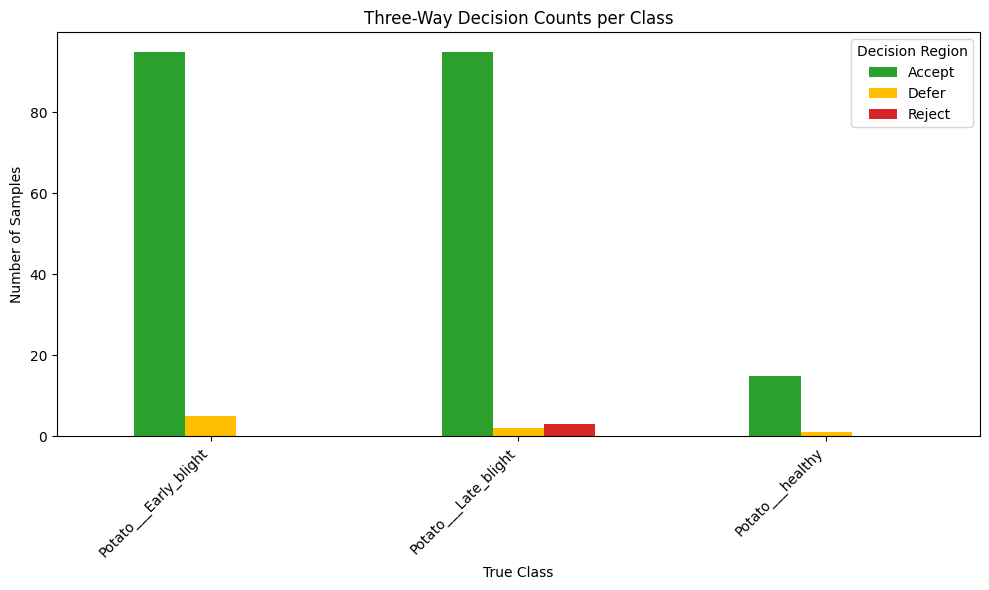

Saved: three_way_decision_counts_mobilenet_3class_seed_123.png


In [22]:
ax = class_region_counts.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#2ca02c", "#ffbf00", "#d62728"]
)

ax.set_title("Three-Way Decision Counts per Class")
ax.set_xlabel("True Class")
ax.set_ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Decision Region")
plt.tight_layout()

three_way_plot = f"three_way_decision_counts_{MODEL_TYPE}_{NUM_CLASSES}class_seed_{SEED_TO_ANALYZE}.png"
plt.savefig(three_way_plot, dpi=300)
plt.show()

print("Saved:", three_way_plot)


In [23]:
SAMPLES_PER_GROUP = 3

OUTPUT_DIR = f"gradcam_{MODEL_TYPE}_{NUM_CLASSES}class_seed_{SEED_TO_ANALYZE}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Grad-CAM output folder:", OUTPUT_DIR)
print("Class names:", class_names)


Grad-CAM output folder: gradcam_mobilenet_3class_seed_123
Class names: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [24]:
analysis_groups = {
    "correct_early_blight": {
        "true": "Potato___Early_blight",
        "pred": "Potato___Early_blight"
    },
    "correct_late_blight": {
        "true": "Potato___Late_blight",
        "pred": "Potato___Late_blight"
    },
    "correct_healthy": {
        "true": "Potato___healthy",
        "pred": "Potato___healthy"
    },
    "early_blight_as_late_blight": {
        "true": "Potato___Early_blight",
        "pred": "Potato___Late_blight"
    },
    "late_blight_as_early_blight": {
        "true": "Potato___Late_blight",
        "pred": "Potato___Early_blight"
    },
    "healthy_as_early_blight": {
        "true": "Potato___healthy",
        "pred": "Potato___Early_blight"
    },
    "healthy_as_late_blight": {
        "true": "Potato___healthy",
        "pred": "Potato___Late_blight"
    }
}

selected_samples = []

for group_name, rule in analysis_groups.items():
    group_df = pred_df[
        (pred_df["true_class"] == rule["true"]) &
        (pred_df["pred_class"] == rule["pred"])
    ].copy()

    group_df = group_df.sort_values("confidence", ascending=False)
    group_df = group_df.head(SAMPLES_PER_GROUP)

    print(f"{group_name}: selected {len(group_df)} samples")

    for _, row in group_df.iterrows():
        sample = row.to_dict()
        sample["group"] = group_name
        selected_samples.append(sample)

selected_df = pd.DataFrame(selected_samples)

selected_csv_path = os.path.join(OUTPUT_DIR, "selected_gradcam_samples.csv")
selected_df.to_csv(selected_csv_path, index=False)

print("Saved selected samples to:", selected_csv_path)
selected_df


correct_early_blight: selected 3 samples
correct_late_blight: selected 3 samples
correct_healthy: selected 3 samples
early_blight_as_late_blight: selected 0 samples
late_blight_as_early_blight: selected 0 samples
healthy_as_early_blight: selected 0 samples
healthy_as_late_blight: selected 0 samples
Saved selected samples to: gradcam_mobilenet_3class_seed_123/selected_gradcam_samples.csv


,image_path,true_label,true_class,predicted_label,pred_class,confidence,correct,group
0,/kaggle/input/datasets/faysalmiah1721758/potat...,0,Potato___Early_blight,0,Potato___Early_blight,0.999994,True,correct_early_blight
1,/kaggle/input/datasets/faysalmiah1721758/potat...,0,Potato___Early_blight,0,Potato___Early_blight,0.999988,True,correct_early_blight
2,/kaggle/input/datasets/faysalmiah1721758/potat...,0,Potato___Early_blight,0,Potato___Early_blight,0.999987,True,correct_early_blight
3,/kaggle/input/datasets/faysalmiah1721758/potat...,1,Potato___Late_blight,1,Potato___Late_blight,1.000000,True,correct_late_blight
4,/kaggle/input/datasets/faysalmiah1721758/potat...,1,Potato___Late_blight,1,Potato___Late_blight,1.000000,True,correct_late_blight
5,/kaggle/input/datasets/faysalmiah1721758/potat...,1,Potato___Late_blight,1,Potato___Late_blight,0.999998,True,correct_late_blight
6,/kaggle/input/datasets/faysalmiah1721758/potat...,2,Potato___healthy,2,Potato___healthy,0.999999,True,correct_healthy
7,/kaggle/input/datasets/faysalmiah1721758/potat...,2,Potato___healthy,2,Potato___healthy,0.999995,True,correct_healthy
8,/kaggle/input/datasets/faysalmiah1721758/potat...,2,Potato___healthy,2,Potato___healthy,0.999993,True,correct_healthy


In [25]:
def find_last_conv_layer(model):
    conv_layer_names = []

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_layer_names.append(layer.name)

    if len(conv_layer_names) == 0:
        raise ValueError("No Conv2D layer found in the model.")

    return conv_layer_names[-1]


last_conv_layer_name = find_last_conv_layer(model)
print("Detected last convolutional layer:", last_conv_layer_name)

dummy_input = tf.zeros((1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
_ = model(dummy_input)

gradcam_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.outputs[0]
    ]
)

print("Grad-CAM model created successfully.")


Detected last convolutional layer: Conv_1
Grad-CAM model created successfully.


In [26]:
def make_gradcam_heatmap(processed_image, gradcam_model, class_index=None):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = gradcam_model(processed_image)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)

    if grads is None:
        raise ValueError("Gradients are None. Grad-CAM graph is disconnected.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def overlay_heatmap(original_image, heatmap, alpha=0.4, cmap="jet"):
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (original_image.shape[0], original_image.shape[1])
    ).numpy().squeeze()

    colormap = plt.get_cmap(cmap)
    colored_heatmap = colormap(heatmap_resized)[:, :, :3]
    colored_heatmap = np.uint8(255 * colored_heatmap)

    overlay = np.uint8(
        alpha * colored_heatmap + (1 - alpha) * original_image
    )

    return overlay


def save_gradcam_figure(sample):
    image_path = sample["image_path"]
    true_class = sample["true_class"]
    pred_class = sample["pred_class"]
    confidence = sample["confidence"]
    group = sample["group"]

    processed_image, original_image = load_image_for_model(image_path)

    pred_index = class_to_idx[pred_class]

    heatmap = make_gradcam_heatmap(
        processed_image=processed_image,
        gradcam_model=gradcam_model,
        class_index=pred_index
    )

    overlay = overlay_heatmap(original_image, heatmap, alpha=0.4)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original_image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title("Grad-CAM Overlay")
    axes[1].axis("off")

    title = (
        f"Group: {group}\n"
        f"True: {true_class} | Predicted: {pred_class} | Confidence: {confidence:.4f}"
    )

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()

    safe_name = os.path.basename(image_path).replace(".", "_")
    save_path = os.path.join(
        OUTPUT_DIR,
        f"{group}_{safe_name}_gradcam.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    return save_path


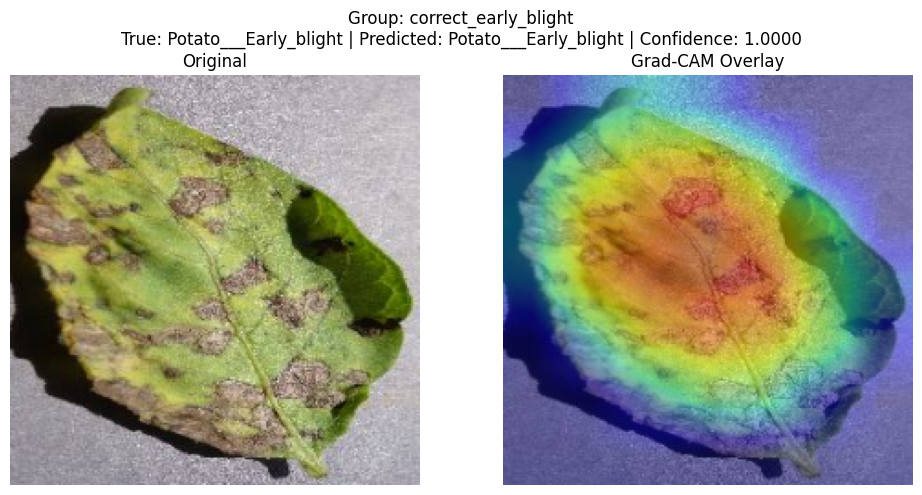

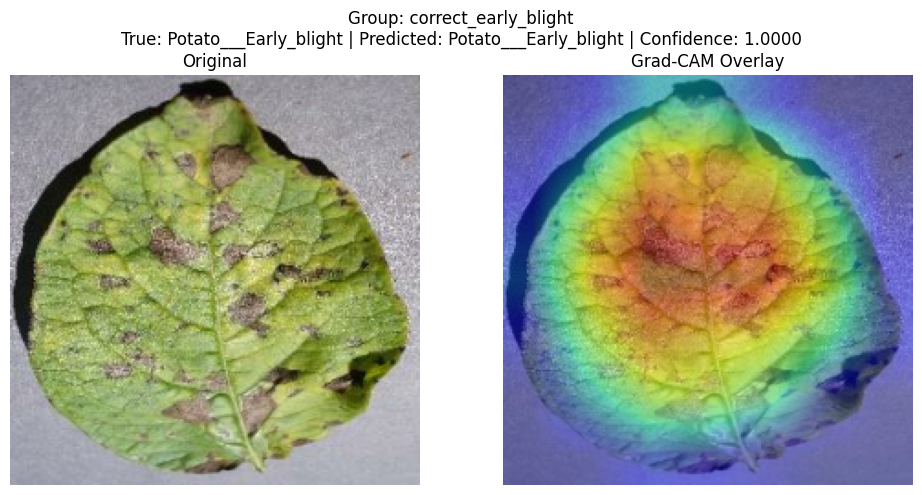

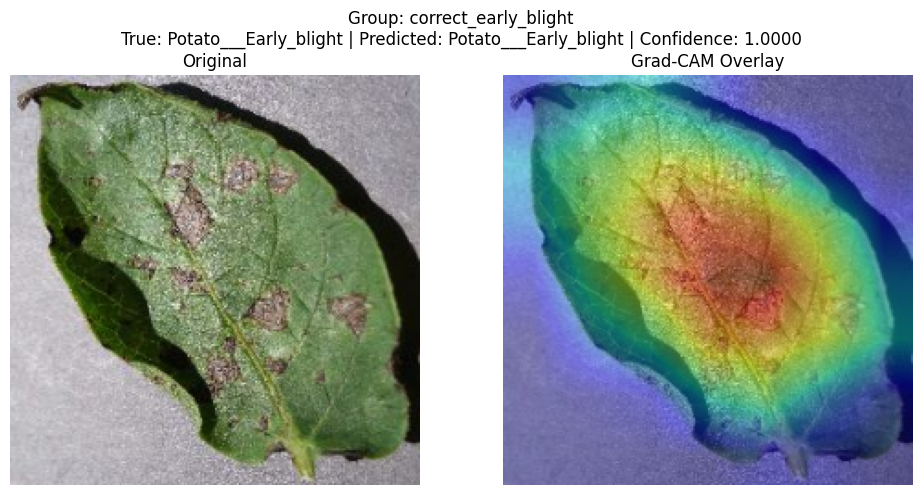

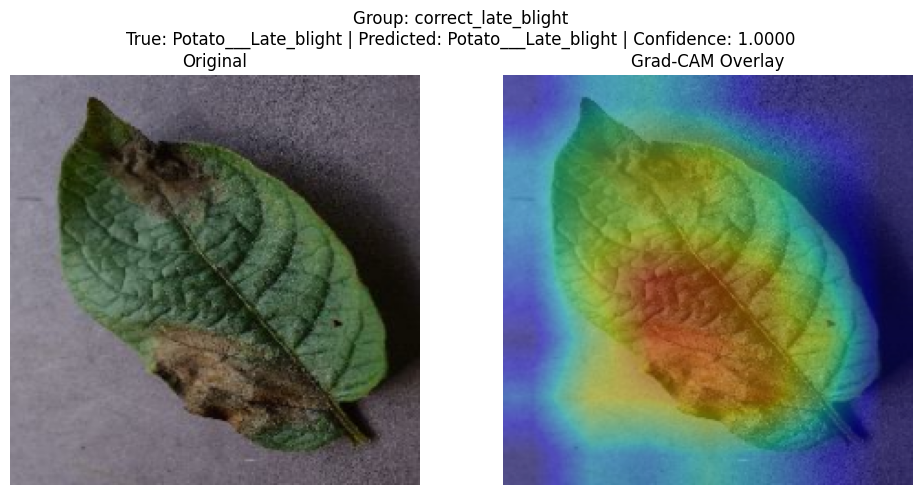

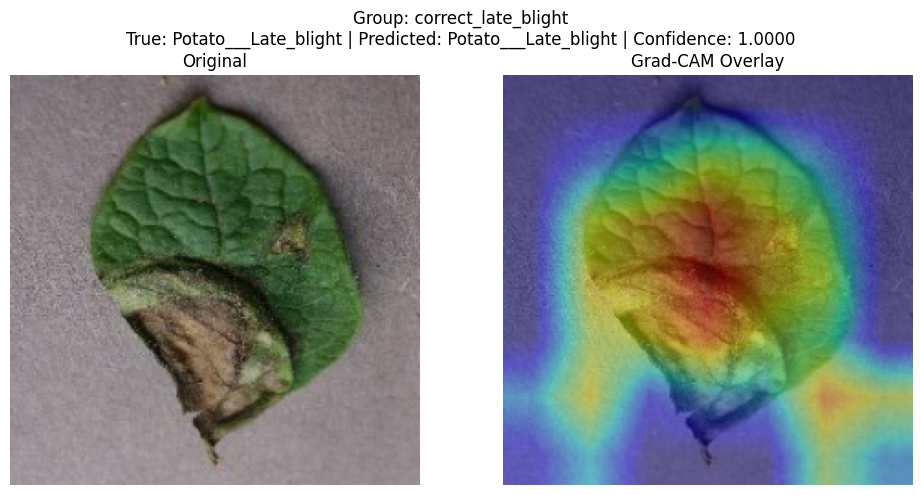

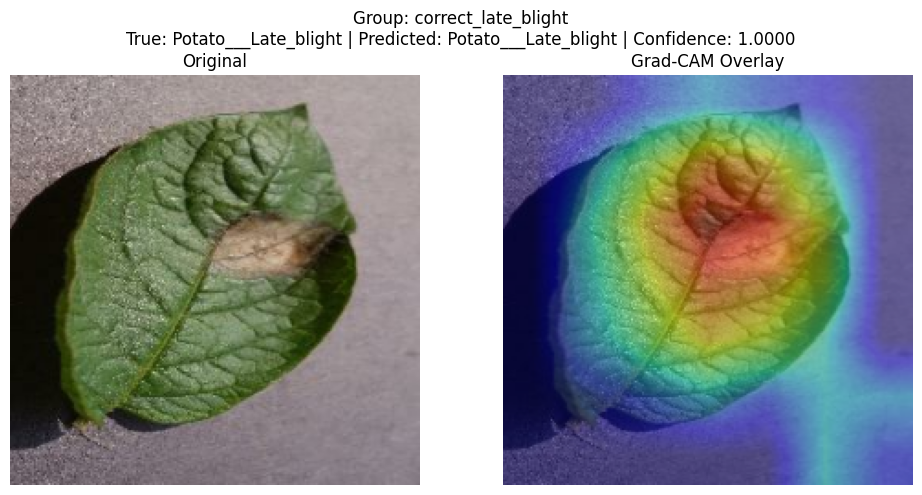

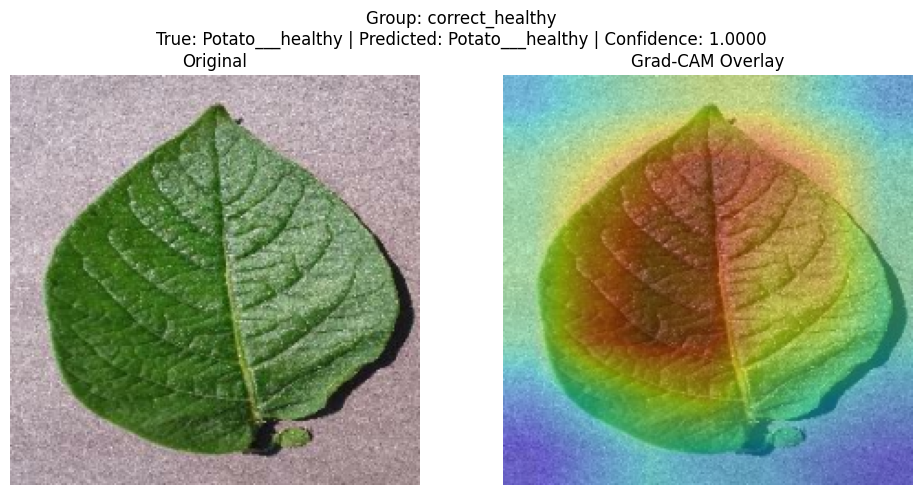

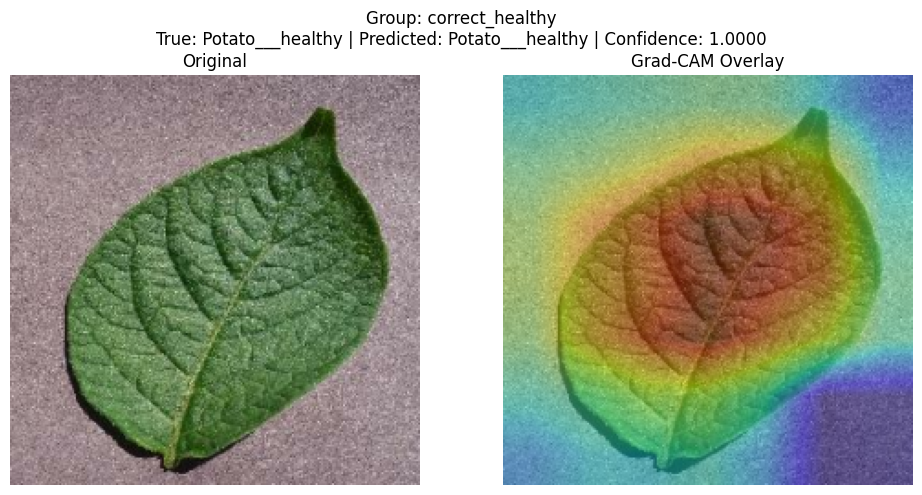

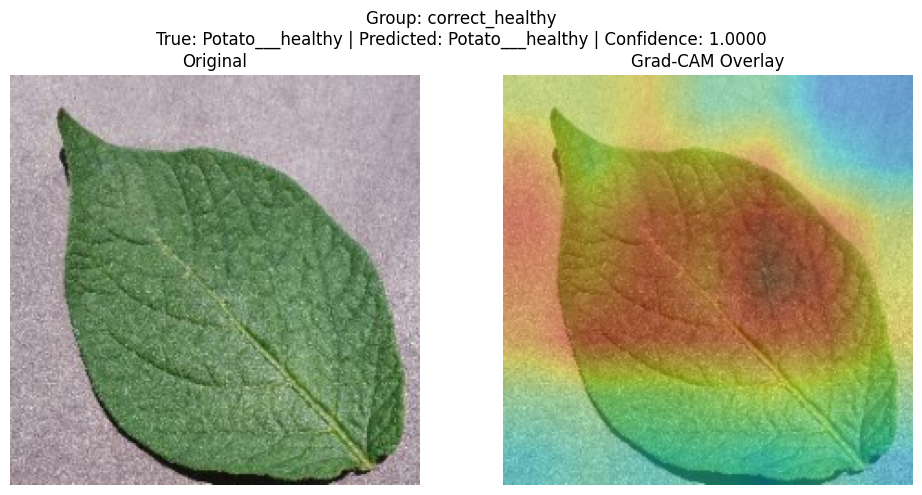


Saved Grad-CAM figures:
gradcam_mobilenet_3class_seed_123/correct_early_blight_6a90d533-28ad-4e1b-935b-8d2dfa804c87___RS_Early_B 8213_JPG_gradcam.png
gradcam_mobilenet_3class_seed_123/correct_early_blight_524142aa-78fb-4fab-895c-ddb993d07479___RS_Early_B 7435_JPG_gradcam.png
gradcam_mobilenet_3class_seed_123/correct_early_blight_12a7bc09-8d7f-4790-8046-6e3f12f71399___RS_Early_B 7973_JPG_gradcam.png
gradcam_mobilenet_3class_seed_123/correct_late_blight_762a9cd9-7da1-4885-b677-870da1e41768___RS_LB 2592_JPG_gradcam.png
gradcam_mobilenet_3class_seed_123/correct_late_blight_3221ccec-f264-4046-8252-77a8a357562b___RS_LB 4637_JPG_gradcam.png
gradcam_mobilenet_3class_seed_123/correct_late_blight_377e9523-f375-4c0c-9d66-5abf2abfaefb___RS_LB 2504_JPG_gradcam.png
gradcam_mobilenet_3class_seed_123/correct_healthy_31a09d39-6791-4ecb-8f44-af2ed85dbd33___RS_HL 1970_JPG_gradcam.png
gradcam_mobilenet_3class_seed_123/correct_healthy_b61b9d33-59ea-41b0-a554-c382eb6128c5___RS_HL 1919_JPG_gradcam.png
gradc

In [27]:
saved_gradcam_paths = []

for _, sample in selected_df.iterrows():
    save_path = save_gradcam_figure(sample)
    saved_gradcam_paths.append(save_path)

print("\nSaved Grad-CAM figures:")
for path in saved_gradcam_paths:
    print(path)


In [28]:
PROJECT_EXPORT_NAME = "ICDM_3class_mobilenet_outputs"

!zip -r {PROJECT_EXPORT_NAME}.zip models history reports {OUTPUT_DIR} *.csv *.png

print("Created:", f"{PROJECT_EXPORT_NAME}.zip")


  adding: models/ (stored 0%)
  adding: models/MobileNetV2_PlantVillage_3class_seed_123.keras (deflated 10%)
  adding: models/MobileNetV2_PlantVillage_3class_seed_42.keras (deflated 10%)
  adding: models/MobileNetV2_PlantVillage_3class_seed_2024.keras (deflated 10%)
  adding: models/MobileNetV2_PlantVillage_3class_seed_777.keras (deflated 10%)
  adding: models/MobileNetV2_PlantVillage_3class_seed_3407.keras (deflated 10%)
  adding: history/ (stored 0%)
  adding: history/MobileNetV2_PlantVillage_3class_seed_2024_confusion_matrix.png (deflated 27%)
  adding: history/MobileNetV2_PlantVillage_3class_seed_123_confusion_matrix.png (deflated 27%)
  adding: history/MobileNetV2_PlantVillage_3class_seed_42_accuracy_loss.png (deflated 15%)
  adding: history/MobileNetV2_PlantVillage_3class_seed_777_history.pkl (deflated 57%)
  adding: history/MobileNetV2_PlantVillage_3class_seed_3407_confusion_matrix.png (deflated 26%)
  adding: history/MobileNetV2_PlantVillage_3class_seed_777_confusion_matrix.png